# Fase inicial de compreensão dos atributos

Inicialmente, será realizado a compreensão de todas as tabelas, para tratamento dos dados. Para isso, será realizado a importação das tabelas e coleta de algumas Informações básicas.

In [ ]:
import os
import re
from sklearn import tree
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns

pd.options.mode.chained_assignment

In [ ]:
df = pd.read_csv('/Users/ryan.oliveira/Desktop/puc/ppl-cd-pcd-sist-int-2025-1-grupo-5-2025-1/assets/data/State_of_data_BR_2023_Kaggle - df_survey_2023.csv')

In [ ]:
df.shape # Número de linhas pelo número de colunas

(5293, 399)

In [ ]:
df.head() # As 5 primeiras linhas do conjunto de dados

,"('P0', 'id')","('P1_a ', 'Idade')","('P1_a_1 ', 'Faixa idade')","('P1_b ', 'Genero')","('P1_c ', 'Cor/raca/etnia')","('P1_d ', 'PCD')","('P1_e ', 'experiencia_profissional_prejudicada')","('P1_e_1 ', 'Não acredito que minha experiência profissional seja afetada')","('P1_e_2 ', 'Experiencia prejudicada devido a minha Cor Raça Etnia')","('P1_e_3 ', 'Experiencia prejudicada devido a minha identidade de gênero')",...,"('P8_d_3 ', 'Entrando em contato com os times de negócio para definição do problema, identificar a solução e apresentação de resultados.')","('P8_d_4 ', 'Desenvolvendo modelos de Machine Learning com o objetivo de colocar em produção em sistemas (produtos de dados).')","('P8_d_5 ', 'Colocando modelos em produção, criando os pipelines de dados, APIs de consumo e monitoramento.')","('P8_d_6 ', 'Cuidando da manutenção de modelos de Machine Learning já em produção, atuando no monitoramento, ajustes e refatoração quando necessário.')","('P8_d_7 ', 'Realizando construções de dashboards em ferramentas de BI como PowerBI, Tableau, Looker, Qlik, etc.')","('P8_d_8 ', 'Utilizando ferramentas avançadas de estatística como SAS, SPSS, Stata etc, para realizar análises.')","('P8_d_9 ', 'Criando e dando manutenção em ETLs, DAGs e automações de pipelines de dados.')","('P8_d_10 ', 'Criando e gerenciando soluções de Feature Store e cultura de MLOps.')","('P8_d_11 ', 'Criando e mantendo a infra que meus modelos e soluções rodam (clusters, servidores, API, containers, etc.)')","('P8_d_12 ', 'Treinando e aplicando LLM's para solucionar problemas de negócio.')"
0,001b2d1qtli8t9z7oqgdhj001b2d4i0g,31,30-34,Masculino,Branca,Não,NaN,NaN,NaN,NaN,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0026aa3fwd78u0026asg7456tfkjg2cs,30,30-34,Masculino,Branca,Não,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,00r21rb9pusd1b0v7ew00r21rw3dy69w,37,35-39,Feminino,Amarela,Não,"Sim, acredito que a minha a experiência profis...",0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,00urm3jf2cek12w6ygue00urm3jzd17j,22,22-24,Masculino,Preta,Não,Não acredito que minha experiência profissiona...,1.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,00v0az4g792svil00vn6y1kfm9hq8vy9,34,30-34,Masculino,Branca,Não,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.columns # Nome de todas as colunas do conjunto de dados2

Index(['('P0', 'id')', '('P1_a ', 'Idade')', '('P1_a_1 ', 'Faixa idade')',
       '('P1_b ', 'Genero')', '('P1_c ', 'Cor/raca/etnia')',
       '('P1_d ', 'PCD')', '('P1_e ', 'experiencia_profissional_prejudicada')',
       '('P1_e_1 ', 'Não acredito que minha experiência profissional seja afetada')',
       '('P1_e_2 ', 'Experiencia prejudicada devido a minha Cor Raça Etnia')',
       '('P1_e_3 ', 'Experiencia prejudicada devido a minha identidade de gênero')',
       ...
       '('P8_d_3 ', 'Entrando em contato com os times de negócio para definição do problema, identificar a solução e apresentação de resultados.')',
       '('P8_d_4 ', 'Desenvolvendo modelos de Machine Learning com o objetivo de colocar em produção em sistemas (produtos de dados).')',
       '('P8_d_5 ', 'Colocando modelos em produção, criando os pipelines de dados, APIs de consumo e monitoramento.')',
       '('P8_d_6 ', 'Cuidando da manutenção de modelos de Machine Learning já em produção, atuando no monitoramento,

In [ ]:
df.info() # O tipo de todas as colunas e quantidade de valores não nulos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5293 entries, 0 to 5292
Columns: 399 entries, ('P0', 'id') to ('P8_d_12 ', 'Treinando e aplicando LLM's para solucionar problemas de negócio.')
dtypes: float64(328), int64(2), object(69)
memory usage: 16.1+ MB


In [ ]:
colunas_codigo = ['P1_i_1', 'P2_h', 'P4_d_1', 'P4_d_2', 'P4_d_3', 'P4_d_4', 'P4_d_5', 
                 'P4_d_6', 'P4_d_7', 'P4_d_8', 'P4_d_9', 'P4_d_10', 'P4_d_11', 
                 'P4_d_12', 'P4_d_13', 'P4_d_14', 'P4_d_15', 'P4_e']

# Procurar strings que contêm os códigos desejados
colunas_selecionadas = []
for codigo in colunas_codigo:
    colunas_correspondentes = [col for col in df.columns if codigo in col]
    if colunas_correspondentes:
        colunas_selecionadas.extend(colunas_correspondentes)

# Criar o DataFrame com as colunas selecionadas
df_atributos_selecionados = df[colunas_selecionadas]

df_atributos_selecionados.columns

Index(['('P1_i_1 ', 'uf onde mora')', '('P2_h ', 'Faixa salarial')',
       '('P4_d_1 ', 'SQL')', '('P4_d_10 ', 'Scala')', '('P4_d_11 ', 'Matlab')',
       '('P4_d_12 ', 'Rust')', '('P4_d_13 ', 'PHP')',
       '('P4_d_14 ', 'JavaScript')',
       '('P4_d_15 ', 'Não utilizo nenhuma linguagem')', '('P4_d_2 ', 'R ')',
       '('P4_d_3 ', 'Python')', '('P4_d_4 ', 'C/C++/C#')',
       '('P4_d_5 ', '.NET')', '('P4_d_6 ', 'Java')', '('P4_d_7 ', 'Julia')',
       '('P4_d_8 ', 'SAS/Stata')', '('P4_d_9 ', 'Visual Basic/VBA')',
       '('P4_d_10 ', 'Scala')', '('P4_d_11 ', 'Matlab')',
       '('P4_d_12 ', 'Rust')', '('P4_d_13 ', 'PHP')',
       '('P4_d_14 ', 'JavaScript')',
       '('P4_d_15 ', 'Não utilizo nenhuma linguagem')',
       '('P4_e ', 'Entre as linguagens listadas abaixo, qual é a que você mais utiliza no trabalho?')'],
      dtype='object')

In [ ]:
df_novo = df_atributos_selecionados.copy()

df_novo.rename(
    columns={ 
        "('P1_i_1 ', 'uf onde mora')": "uf_onde_mora",
        "('P2_h ', 'Faixa salarial')": "faixa_salarial",
        "('P4_d_1 ', 'SQL')": "sql",
        "('P4_d_2 ', 'R ')": "r",
        "('P4_d_3 ', 'Python')": "python",
        "('P4_d_4 ', 'C/C++/C#')": "c_cpp_csharp",
        "('P4_d_5 ', '.NET')": "dotnet",
        "('P4_d_6 ', 'Java')": "java",
        "('P4_d_7 ', 'Julia')": "julia",
        "('P4_d_8 ', 'SAS/Stata')": "sas_stata",
        "('P4_d_9 ', 'Visual Basic/VBA')": "vb_vba",
        "('P4_d_10 ', 'Scala')": "scala",
        "('P4_d_11 ', 'Matlab')": "matlab",
        "('P4_d_12 ', 'Rust')": "rust",
        "('P4_d_13 ', 'PHP')": "php",
        "('P4_d_14 ', 'JavaScript')": "javascript",
        "('P4_d_15 ', 'Não utilizo nenhuma linguagem')": "nao_utiliza_linguagem",
        "('P4_e ', 'Entre as linguagens listadas abaixo, qual é a que você mais utiliza no trabalho?')": "linguagem_principal",
        },
    inplace=True
)

Há algumas respostas dadas como 'NaN', isto é, não é um número, podemos asssumir que a resposta seria nula, no caso do nosso contexto, a resposta seria '0' representando o negativo.

In [ ]:
df_novo.isna().sum()

uf_onde_mora              124
faixa_salarial            540
sql                      1521
scala                    1521
matlab                   1521
rust                     1521
php                      1521
javascript               1521
nao_utiliza_linguagem    1521
r                        1521
python                   1521
c_cpp_csharp             1521
dotnet                   1521
java                     1521
julia                    1521
sas_stata                1521
vb_vba                   1521
scala                    1521
matlab                   1521
rust                     1521
php                      1521
javascript               1521
nao_utiliza_linguagem    1521
linguagem_principal      1521
dtype: int64

In [ ]:
colunas_linguagem = ['sql', 'scala', 'matlab', 'rust', 'php', 'javascript', 'nao_utiliza_linguagem', 
           'r', 'python', 'c_cpp_csharp', 'dotnet', 'java', 'julia', 'sas_stata', 'vb_vba']

# Preencher NaN com 0 em cada coluna
for coluna in colunas_linguagem:
    if coluna in df_novo.columns:
        df_novo[coluna] = df_novo[coluna].fillna(0)

In [ ]:
# Quantidade de 1 (Ou positivos) por linguagem
(df_novo[colunas_linguagem] == 1).sum()

sql                      3156
scala                     131
scala                     131
matlab                     30
matlab                     30
rust                        7
rust                        7
php                        56
php                        56
javascript                282
javascript                282
nao_utiliza_linguagem     305
nao_utiliza_linguagem     305
r                         408
python                   2825
c_cpp_csharp               70
dotnet                     40
java                      355
julia                       8
sas_stata                 151
vb_vba                    285
dtype: int64

Há alguns atributos duplicados devido a cópia, dessa forma, iremos remover os arquivos duplicados pela primeira ocorrência.

In [ ]:
# Remover todas as colunas duplicadas (mantendo a primeira ocorrência)
df_novo = df_novo.loc[:, ~df_novo.columns.duplicated()]

In [ ]:
duplicadas = df_novo.columns[df_novo.columns.duplicated()]
print("Colunas duplicadas:", duplicadas.tolist())


Colunas duplicadas: []


In [ ]:
(df_novo[colunas_linguagem] == 1).sum()

sql                      3156
scala                     131
matlab                     30
rust                        7
php                        56
javascript                282
nao_utiliza_linguagem     305
r                         408
python                   2825
c_cpp_csharp               70
dotnet                     40
java                      355
julia                       8
sas_stata                 151
vb_vba                    285
dtype: int64

Criação de uma coluna chamada 'linguagens_estatisticas_analise_dados' para otimização de atributos, agrupando as linguagens Julia, R, Matlab, Scala e SAS/Stata.

In [ ]:
df_novo['linguagens_estatisticas_analise_dados'] = df_novo[['julia', 'r', 'matlab', 'scala', 'sas_stata']].any(axis=1).astype(int)
df_novo.drop(['julia', 'r', 'matlab', 'scala', 'sas_stata'], axis=1, inplace=True)

In [ ]:
colunas_linguagem = ['sql', 'rust', 'php', 'javascript', 'nao_utiliza_linguagem', 'python', 'c_cpp_csharp', 'dotnet', 'java',  'vb_vba', 'linguagens_estatisticas_analise_dados']
(df_novo[colunas_linguagem] == 1).sum()

sql                                      3156
rust                                        7
php                                        56
javascript                                282
nao_utiliza_linguagem                     305
python                                   2825
c_cpp_csharp                               70
dotnet                                     40
java                                      355
vb_vba                                    285
linguagens_estatisticas_analise_dados     653
dtype: int64

Por fim, o ideal é que haja outra otimização para a aplicação dos modelos. No caso, será criado 3 atributos novos, para agrupar outros tipos de linguagens. Sendo elas:

1. Linguagens Web (linguagens_web): javascript e php;
2. Linguagens Empresariais (linguagens_empresariais): java, dotnet e vb_vba
3. Linguagens de Sistemas (linguagens_sistemas): c_cpp_csharp e rust

In [ ]:
df_novo['linguagens_web'] = df_novo[['javascript', 'php']].any(axis=1).astype(int)
df_novo.drop(['javascript', 'php'], axis=1, inplace=True)

In [ ]:
df_novo['linguagens_empresariais'] = df_novo[['java', 'dotnet', 'vb_vba']].any(axis=1).astype(int)
df_novo.drop(['java', 'dotnet', 'vb_vba'], axis=1, inplace=True)

In [ ]:
df_novo['linguagens_sistemas'] = df_novo[['c_cpp_csharp', 'rust']].any(axis=1).astype(int)
df_novo.drop(['c_cpp_csharp', 'rust'], axis=1, inplace=True)

In [ ]:
colunas_linguagem = ['sql', 'nao_utiliza_linguagem', 'python', 'linguagens_estatisticas_analise_dados', 'linguagens_web', 'linguagens_empresariais', 'linguagens_sistemas']
(df_novo[colunas_linguagem] == 1).sum().sort_values()

linguagens_sistemas                        76
linguagens_web                            304
nao_utiliza_linguagem                     305
linguagens_empresariais                   626
linguagens_estatisticas_analise_dados     653
python                                   2825
sql                                      3156
dtype: int64

Após a otimização de alguns atributos, prevalecendo aqueles com maior recorrência, será necessário transformar o atributo 'Faixa Salarial' para um valor float. Com isso, será possível fazer algumas predições.

In [ ]:
df_novo['faixa_salarial'].value_counts()

faixa_salarial
de R$ 8.001/mês a R$ 12.000/mês     1026
de R$ 4.001/mês a R$ 6.000/mês       745
de R$ 12.001/mês a R$ 16.000/mês     650
de R$ 6.001/mês a R$ 8.000/mês       637
de R$ 3.001/mês a R$ 4.000/mês       352
de R$ 16.001/mês a R$ 20.000/mês     328
de R$ 2.001/mês a R$ 3.000/mês       288
de R$ 1.001/mês a R$ 2.000/mês       215
de R$ 20.001/mês a R$ 25.000/mês     195
de R$ 25.001/mês a R$ 30.000/mês     128
de R$ 30.001/mês a R$ 40.000/mês      86
Acima de R$ 40.001/mês                72
Menos de R$ 1.000/mês                 30
de R$ 101/mês a R$ 2.000/mês           1
Name: count, dtype: int64

In [ ]:
def converter_faixa_salarial(faixa):
    if faixa == "de R$ 8.001/mês a R$ 12.000/mês":
        return 10000.50
    elif faixa  == "de R$ 4.001/mês a R$ 6.000/mês":
        return 5000.50
    elif faixa == "de R$ 12.001/mês a R$ 16.000/mês":
        return 14000.50
    elif faixa == "de R$ 6.001/mês a R$ 8.000/mês":
        return 7000.50
    elif faixa == "de R$ 3.001/mês a R$ 4.000/mês":
        return 3500.50
    elif faixa == "de R$ 16.001/mês a R$ 20.000/mês":
        return 18000.50
    elif faixa == "de R$ 2.001/mês a R$ 3.000/mês":
        return 2500.50
    elif faixa == "de R$ 1.001/mês a R$ 2.000/mês":
        return 1500.50
    elif faixa == "de R$ 20.001/mês a R$ 25.000/mês":
        return 22500.50
    elif faixa == "de R$ 25.001/mês a R$ 30.000/mês":
        return 27500.50
    elif faixa == "de R$ 30.001/mês a R$ 40.000/mês":
        return 35000.50
    elif faixa == "Acima de R$ 40.001/mês":
        return 50000.00
    elif faixa == "Menos de R$ 1.000/mês":
        return 500.00
    elif faixa == "de R$ 101/mês a R$ 2.000/mês":
        1050.50

In [ ]:
df_novo['salario_medio'] = df_novo['faixa_salarial'].apply(converter_faixa_salarial)

In [ ]:
df_novo['salario_medio'].value_counts()

salario_medio
10000.5    1026
5000.5      745
14000.5     650
7000.5      637
3500.5      352
18000.5     328
2500.5      288
1500.5      215
22500.5     195
27500.5     128
35000.5      86
50000.0      72
500.0        30
Name: count, dtype: int64

In [ ]:
df_novo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5293 entries, 0 to 5292
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   uf_onde_mora                           5169 non-null   object 
 1   faixa_salarial                         4753 non-null   object 
 2   sql                                    5293 non-null   float64
 3   nao_utiliza_linguagem                  5293 non-null   float64
 4   python                                 5293 non-null   float64
 5   linguagem_principal                    3772 non-null   object 
 6   linguagens_estatisticas_analise_dados  5293 non-null   int64  
 7   linguagens_web                         5293 non-null   int64  
 8   linguagens_empresariais                5293 non-null   int64  
 9   linguagens_sistemas                    5293 non-null   int64  
 10  salario_medio                          4752 non-null   float64
dtypes: f

## Tratamento de valores nulos para aplicação do modelo.

In [ ]:
df_novo.isnull().sum()

uf_onde_mora                              124
faixa_salarial                            540
sql                                         0
nao_utiliza_linguagem                       0
python                                      0
linguagem_principal                      1521
linguagens_estatisticas_analise_dados       0
linguagens_web                              0
linguagens_empresariais                     0
linguagens_sistemas                         0
salario_medio                             541
dtype: int64

In [ ]:
# Os dados referentes ao UF irei aplicar como Não Informados (NI)
df_novo['uf_onde_mora'].fillna('NI', inplace=True)

/var/folders/p1/vrkk65316532v7sjv657d7pc0000gq/T/ipykernel_15577/3975669399.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_novo['uf_onde_mora'].fillna('NI', inplace=True)


In [ ]:
# Para faixa salarial
df_novo['faixa_salarial'] = df_novo['faixa_salarial'].fillna('Não informado')

# Para salário médio
df_novo['salario_medio'] = df_novo['salario_medio'].fillna(df_novo['salario_medio'].mean())

In [ ]:
# Baixa adesão, logo será necessário um drop.
df_novo.drop('linguagem_principal', axis=1, inplace=True)

In [ ]:
df_novo.isnull().sum()

uf_onde_mora                             0
faixa_salarial                           0
sql                                      0
nao_utiliza_linguagem                    0
python                                   0
linguagens_estatisticas_analise_dados    0
linguagens_web                           0
linguagens_empresariais                  0
linguagens_sistemas                      0
salario_medio                            0
dtype: int64

# Aplicação do Modelo: Árvore de Decisão

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn import tree

In [ ]:
# Variáveis independentes
X = df_novo.drop(['salario_medio', 'faixa_salarial'], axis=1)

# Variável alvo (valor que queremos prever)
y = df_novo['salario_medio'] # (Regressão)

In [ ]:
# Identificar colunas categóricas e numéricas
categorical_cols = ['uf_onde_mora']
numerical_cols = ['sql', 'python', 'nao_utiliza_linguagem', 
                  'linguagens_estatisticas_analise_dados',
                  'linguagens_web', 'linguagens_empresariais', 
                  'linguagens_sistemas']

# Criar preprocessador
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

In [ ]:
# Para regressão (prever salário exato)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(max_depth=5))  # Limitar profundidade para evitar overfitting
])

# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Treinar o modelo
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['uf_onde_mora']),
                                                 ('num', 'passthrough',
                                                  ['sql', 'python',
                                                   'nao_utiliza_linguagem',
                                                   'linguagens_estatisticas_analise_dados',
                                                   'linguagens_web',
                                                   'linguagens_empresariais',
                                                   'linguagens_sistemas'])])),
                ('regressor', DecisionTreeRegressor(max_depth=5))])

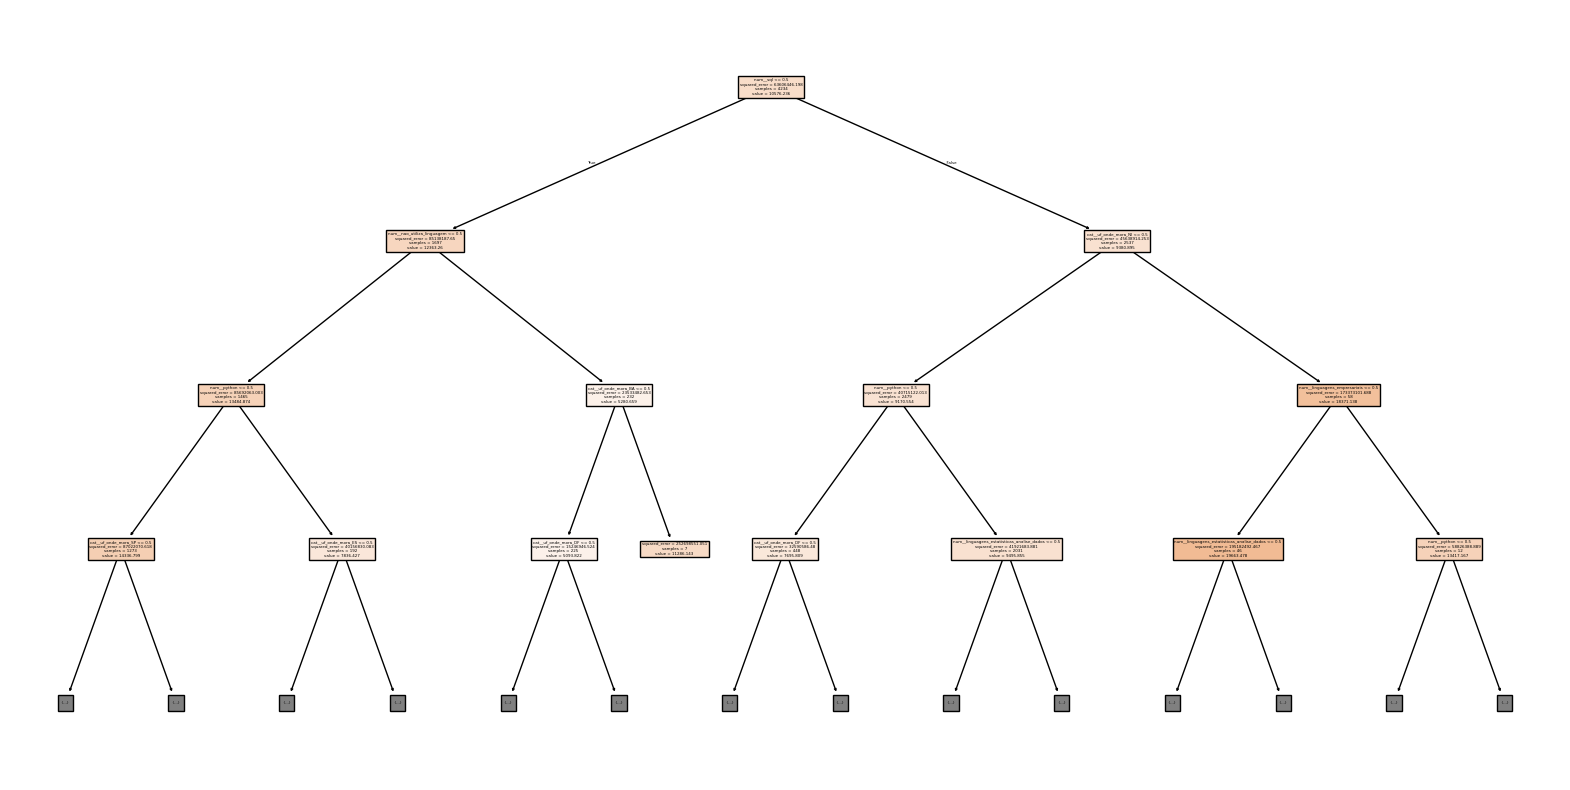

In [ ]:
# Treinar o modelo primeiro
pipeline.fit(X_train, y_train)

# Extrair os nomes das features transformadas do pipeline
feature_names_transformed = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Visialização da Arvore
tree_model = pipeline.named_steps['regressor']
plt.figure(figsize=(20, 10))
tree.plot_tree(tree_model, 
               feature_names=feature_names_transformed,
               filled=True, 
               max_depth=3)
plt.show()

In [ ]:
# Importância das características
tree_model = pipeline.named_steps['regressor']
importances = tree_model.feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

if len(importances) == len(feature_names):
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    print(importance_df.head(10))  # Top 10 fatores mais importantes
else:
    print(f"Erro: Número de importâncias ({len(importances)}) não corresponde ao número de features ({len(feature_names)})")

                                       Feature  Importance
28                  num__nao_utiliza_linguagem    0.279323
26                                    num__sql    0.187397
27                                 num__python    0.176480
12                        cat__uf_onde_mora_NI    0.133078
24                        cat__uf_onde_mora_SP    0.109872
31                num__linguagens_empresariais    0.064240
29  num__linguagens_estatisticas_analise_dados    0.019601
5                         cat__uf_onde_mora_DF    0.010843
15                        cat__uf_onde_mora_PE    0.005709
3                         cat__uf_onde_mora_BA    0.005394
